In [ ]:
# Objective of this Project -
#  - Extarct real data from Yahoo Finance
#  - Create a Predictive Model using Deep Learning MLP to predict the closing price
#  - save the Model for real-time use



In [54]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import r2_score

In [ ]:

def stock_data_extraction(ticker):
  try:
    data = yf.download(ticker,period = "6mo", interval="1d")
    # print("Raw Stock Data - ")
    # print(data.head(2))
    return data
  except Exception as e:
    print("Issue in stock_data_extraction fucntion \n", e)

In [ ]:

def data_prep(data):
  try:
    data.columns = data.columns.droplevel(1)
    data.reset_index(inplace = True)
    final_df = data[['Close', 'High', 'Low', 'Open', 'Volume']]
    # print(final_df.head(3))
    return final_df
  except Exception as e:
    print("Error in data_prep function\n", e)

In [ ]:

scaler = MinMaxScaler()
def feature_transformation(data):
  scaled = scaler.fit_transform(data)
  return scaled

In [69]:
data = stock_data_extraction("AAPL")
final_df = data_prep(data)
scaled_df = feature_transformation(final_df)
scaled_df

/tmp/ipython-input-2833326.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,period = "6mo", interval="1d")
[*********************100%***********************]  1 of 1 completed


array([[0.        , 0.        , 0.        , 0.00165838, 0.08715997],
       [0.04645304, 0.04119901, 0.02725995, 0.        , 0.16846384],
       [0.03670757, 0.0445654 , 0.04097322, 0.00514008, 0.08964162],
       [0.0716288 , 0.04761156, 0.01521877, 0.0116072 , 0.25141825],
       [0.09079494, 0.07021488, 0.07492304, 0.04045947, 0.09153697],
       [0.1244165 , 0.11045245, 0.09298491, 0.07710515, 0.13827061],
       [0.11759465, 0.10997145, 0.12693434, 0.10512791, 0.14748472],
       [0.07828825, 0.06941353, 0.0533493 , 0.05107174, 0.17942038],
       [0.22040883, 0.19766019, 0.17693898, 0.18306213, 0.33269538],
       [0.24168611, 0.21449221, 0.2167418 , 0.20362309, 0.20324116],
       [0.2402243 , 0.23725615, 0.24600859, 0.22932472, 0.25344321],
       [0.21082577, 0.21849994, 0.21005211, 0.21771767, 0.21318488],
       [0.15349025, 0.19653775, 0.1602149 , 0.17957969, 0.33191434],
       [0.03069795, 0.09458174, 0.03629077, 0.09982189, 0.44935806],
       [0.08332326, 0.06300096, 0.

In [70]:
close_index = final_df.columns.get_loc('Close')
close_index

0

In [71]:
X = scaled_df[:-1]  ### all rows except the last
y = scaled_df[1:,close_index]   #### All rows except the firsdyt (close column only)

In [ ]:
print(X.shape)
print(y.shape)

(125, 5)
(125,)


In [72]:
split = int(len(X) * 0.8)
X_train = X[:split]  ### rows till split (80)
X_test = X[split:]  ### ROWs from split till end (80- 100)
y_train =y[:split]
y_test = y[split:]

In [ ]:

model = Sequential()
model.add(Dense(64, activation='relu', input_dim = 5))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(optimizer = 'adam',loss = 'mse')

model.fit(X_train,y_train, epochs = 50,verbose = True)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1240 
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0525
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0127
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0082
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0091
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0059
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0035
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0042
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0033
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0033
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0040
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0036
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15m

In [82]:
pred = model.predict(X_test)
print(r2_score(y_test, pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
0.6285430137768802


In [75]:
### convert back to real prices
### Need to create a dummy array
dummy = np.zeros((len(pred),5))
dummy[:,close_index] = pred.flatten()

In [76]:
predicted_close = scaler.inverse_transform(dummy)[:,close_index]
predicted_close

array([259.61191107, 259.7743675 , 258.69009515, 251.75150331,
       250.04598911, 250.4403875 , 248.74675518, 254.0295085 ,
       259.81717741, 257.51511911, 258.90726535, 258.67879931,
       264.07356604, 269.33089641, 274.46314477, 275.75529865,
       276.61791397, 274.97065539, 273.28815042, 274.82465191,
       269.94607279, 260.36193793, 260.65789697, 263.88333152,
       261.9607277 ])

In [ ]:

dummy[:, close_index] = y_test
actaul_close = scaler.inverse_transform(dummy)[:,close_index]

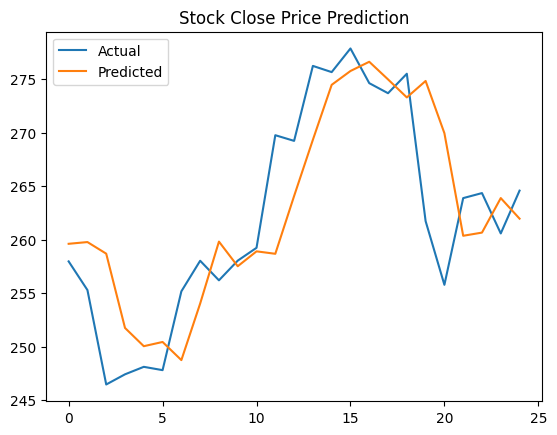

In [80]:
import matplotlib.pyplot as plt
plt.plot(actaul_close, label = "Actual")
plt.plot(predicted_close, label = 'Predicted')
plt.legend()
plt.title("Stock Close Price Prediction")
plt.show()

In [83]:
sp500 = yf.download("^GSPC",period = "6mo", interval="1d")['Close']
sp500

/tmp/ipython-input-450732591.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC",period = "6mo", interval="1d")['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2025-08-21,6370.169922
2025-08-22,6466.910156
2025-08-25,6439.319824
2025-08-26,6465.939941
2025-08-27,6481.399902
...,...
2026-02-13,6836.169922
2026-02-17,6843.220215
2026-02-18,6881.310059


In [84]:
nifty50 = yf.download("^NSEI",period = "6mo", interval="1d")['Close']
nifty50

/tmp/ipython-input-2679737122.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty50 = yf.download("^NSEI",period = "6mo", interval="1d")['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^NSEI
Date,
2025-08-20,25050.550781
2025-08-21,25083.750000
2025-08-22,24870.099609
2025-08-25,24967.750000
2025-08-26,24712.050781
...,...
2026-02-16,25682.750000
2026-02-17,25725.400391
2026-02-18,25819.349609
